<a href="https://colab.research.google.com/github/JevonLRobinson/Patient-Analysis/blob/main/Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load packages and begin data preparation

In [8]:
# Load packages
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Load training data & drop target columns
train_df = pd.read_csv("/content/diabetic_data.csv")
X_train = train_df.drop(columns=["encounter_id", "readmitted"])
y_train = train_df["readmitted"]

# Encode categorical columns
non_num_cols = X_train.select_dtypes(include='object').columns
for col in non_num_cols:
    X_train[col] = X_train[col].fillna("missing")
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])

# Preprocess numerical columns
num_cols = X_train.select_dtypes(include=np.number).columns
for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train[col].median())

# Split data into training and testing sets (70/30 split)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

# Predict on test dataset: Get encounter_ids for the validation set from the original train_df
encounter_ids = train_df.loc[X_val_split.index, "encounter_id"]
X_test = X_val_split.copy()

# Begin predictions
y_proba = model.predict_proba(X_test)[:, 1]

Show feature importance that influence readmission within 30 days

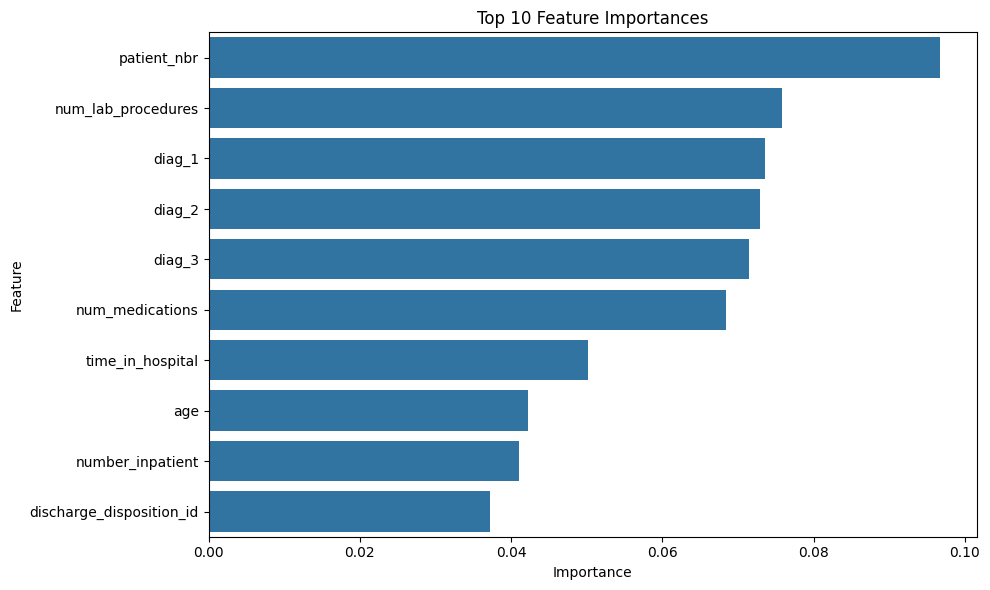

Top 10 Features selected for analysis:
['patient_nbr', 'num_lab_procedures', 'diag_1', 'diag_2', 'diag_3', 'num_medications', 'time_in_hospital', 'age', 'number_inpatient', 'discharge_disposition_id']


In [13]:
# Build out visual for top 10 important features that influence if a patient is readmitted
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Create a binary target for 'readmitted within 30 days'
train_df['readmitted_30_days'] = (train_df['readmitted'] == '<30').astype(int)

# Combine preprocessed features (X_train) with the new binary target
df_analysis = X_train.copy()
df_analysis['readmitted_30_days'] = train_df['readmitted_30_days']

# Get top 10 features from the previously calculated feature_importances
top_10_features = feature_importances['feature'].head(10).tolist()

print("Top 10 Features selected for analysis:")
print(top_10_features)

#### Distribution Graphs of Top Features vs. Readmission Status

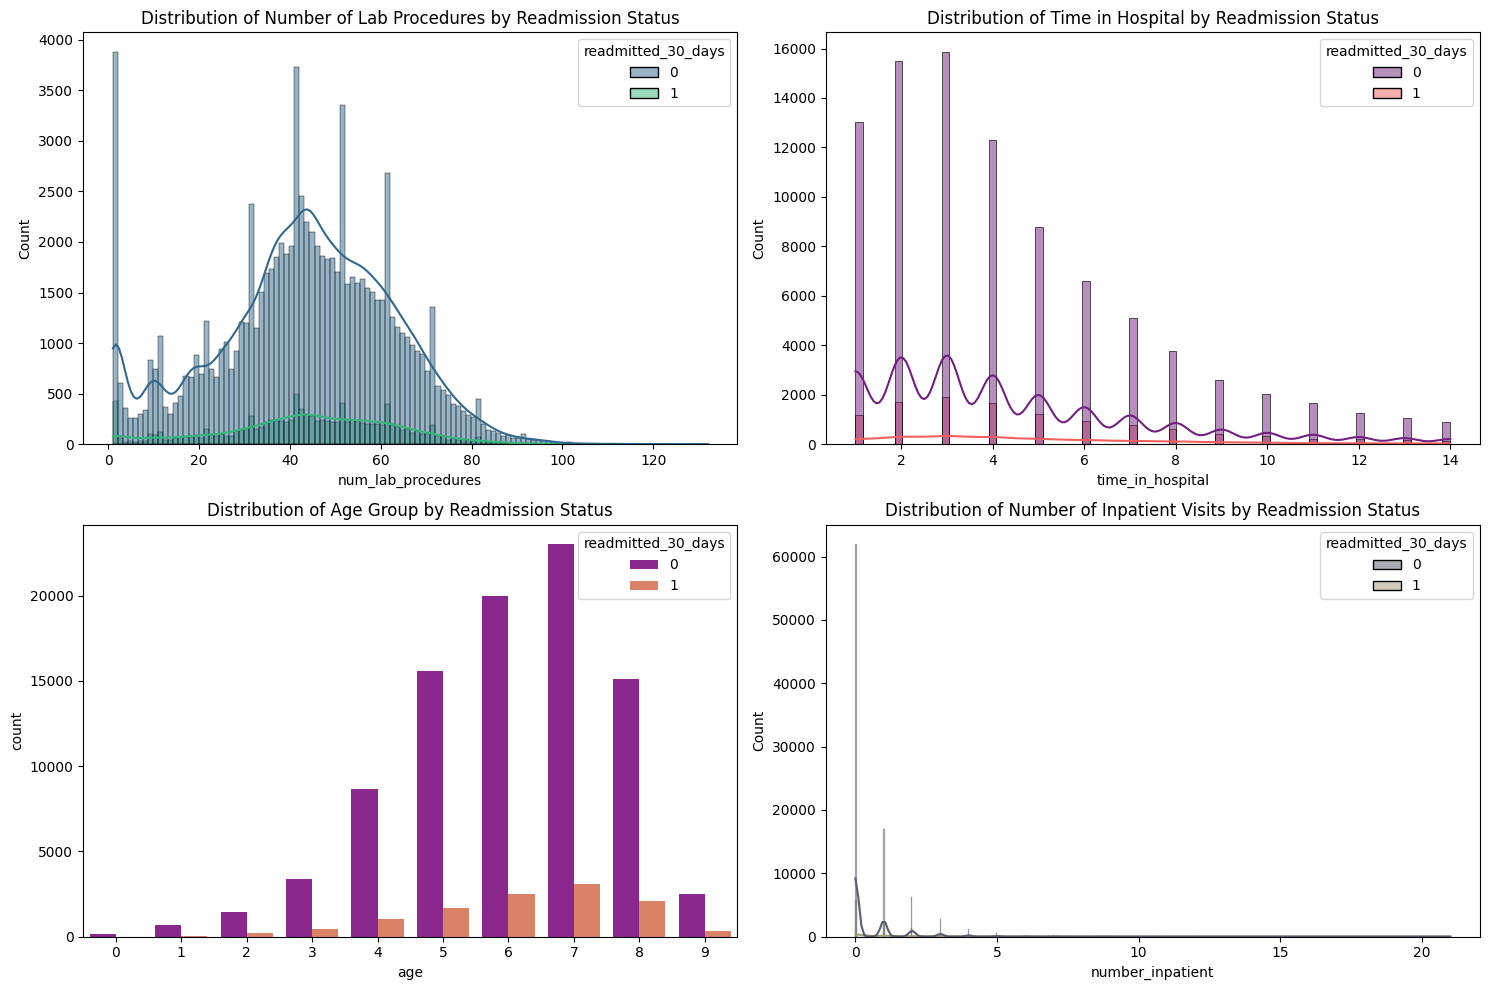

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions for a few key features
# Select interpretable features from the top list.
# Re-extract relevant columns from df_analysis, including the target
df_plot = df_analysis[top_10_features + ['readmitted_30_days']]

plt.figure(figsize=(15, 10))

# Plot for 'num_lab_procedures'
plt.subplot(2, 2, 1)
sns.histplot(data=df_plot, x='num_lab_procedures', hue='readmitted_30_days', kde=True, palette='viridis')
plt.title('Distribution of Number of Lab Procedures by Readmission Status')

# Plot for 'time_in_hospital'
plt.subplot(2, 2, 2)
sns.histplot(data=df_plot, x='time_in_hospital', hue='readmitted_30_days', kde=True, palette='magma')
plt.title('Distribution of Time in Hospital by Readmission Status')

# Plot for 'age' (encoded categorical)
plt.subplot(2, 2, 3)
sns.countplot(data=df_plot, x='age', hue='readmitted_30_days', palette='plasma')
plt.title('Distribution of Age Group by Readmission Status')

# Plot for 'number_inpatient'
plt.subplot(2, 2, 4)
sns.histplot(data=df_plot, x='number_inpatient', hue='readmitted_30_days', kde=True, palette='cividis')
plt.title('Distribution of Number of Inpatient Visits by Readmission Status')

plt.tight_layout()
plt.show()

#### Correlation Matrix of Top Features

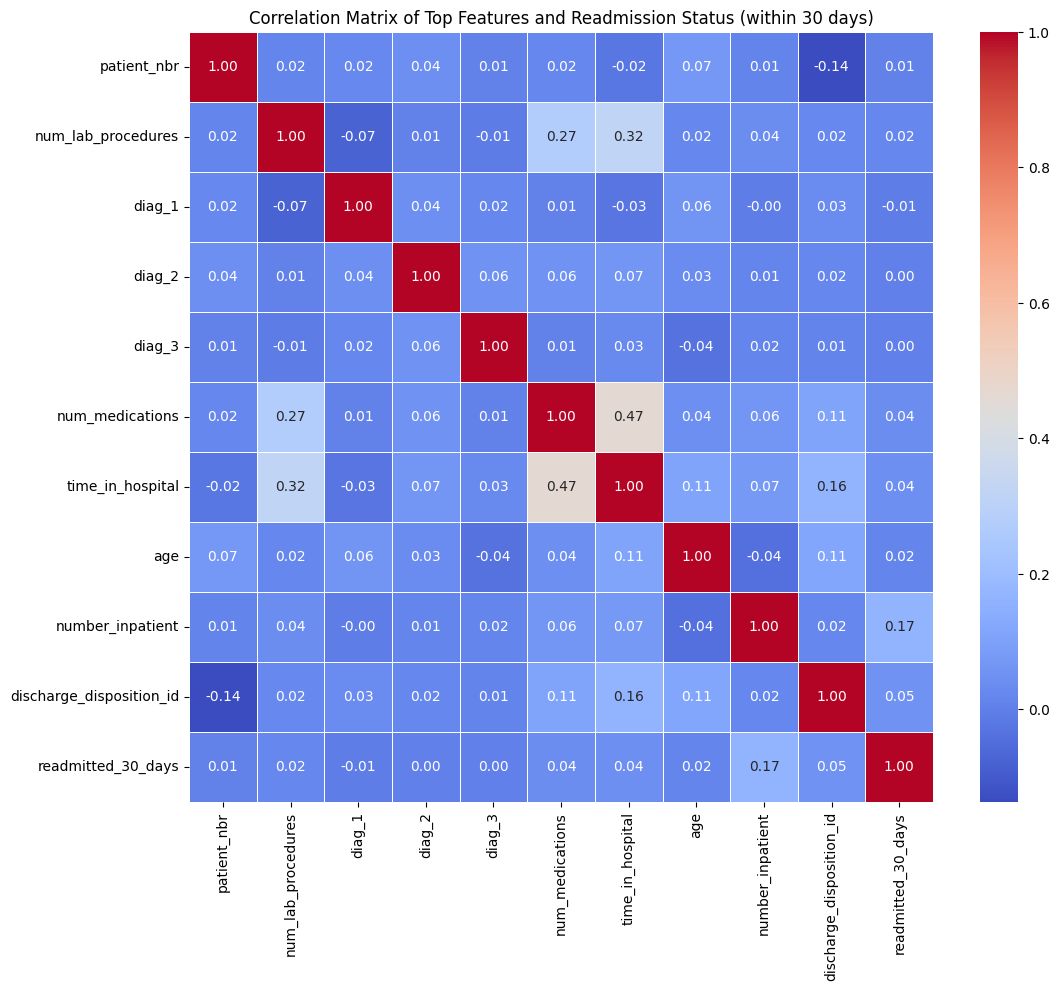

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 features and the binary target for correlation matrix
correlation_data = df_analysis[top_10_features + ['readmitted_30_days']]

# Calculate the correlation matrix
corr_matrix = correlation_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Top Features and Readmission Status (within 30 days)')
plt.show()